# 🏷️ Phase 2 — Seed Tag OCR & Agronomic Metadata Encoding

Phase 2 extracts structured agronomic context from seed packets, tags, and farmer field logs:
1. **Computer Vision Preprocessing:** Deskewing, grayscale conversion, and adaptive thresholding for text isolation.
2. **Text Recognition (OCR):** Tesseract 5 engine + fuzzy matching against known African maize cultivars (e.g. *SAMMAZ 15*, *OBA SUPER 2*, *EVDT 99*).
3. **Regex Extraction:** Extracting production batch numbers and ISO planting dates.
4. **Metadata Vectorization:** Compiling extracted context into a fixed-length 17-dimensional continuous vector for downstream multimodal fusion.


In [1]:
# Setup & Imports
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

from src.phase2_ocr.extractor import (
    extract_fields,
    KNOWN_VARIETIES,
    _extract_variety,
    _extract_batch,
    _extract_date,
)
from src.phase2_ocr.encoder import encode, METADATA_DIM, NUM_VARIETIES
from src.phase2_ocr.preprocessor import preprocess

print(f"Known Maize Cultivars: {len(KNOWN_VARIETIES)} varieties ({', '.join(KNOWN_VARIETIES[:5])}...)")
print(f"Encoded Metadata Vector Dimensions: {METADATA_DIM}")


Known Maize Cultivars: 13 varieties (SAMMAZ 15, SAMMAZ 17, SAMMAZ 29, SAMMAZ 34, SAMMAZ 50...)
Encoded Metadata Vector Dimensions: 17


### 1. Synthetic Seed Tag Generation & Preprocessing

In [2]:
# Create a synthetic seed tag image to demonstrate OCR pipeline
tag_img = Image.new("RGB", (650, 240), color=(245, 243, 235))
draw = ImageDraw.Draw(tag_img)

# Draw simulated seed tag content
draw.rectangle([10, 10, 640, 230], outline=(70, 70, 70), width=3)
draw.text((30, 25), "NATIONAL AGRICULTURAL SEEDS COUNCIL", fill=(20, 20, 20))
draw.text((30, 60), "CROP VARIETY : SAMMAZ 15 (HYBRID)", fill=(0, 0, 140))
draw.text((30, 100), "BATCH NUMBER : LOT-2024-007", fill=(30, 30, 30))
draw.text((30, 140), "SOWING DATE  : 15/04/2024", fill=(30, 30, 30))
draw.text((30, 180), "PURITY: 99.2% | GERMINATION: 94%", fill=(40, 40, 40))

# Convert to OpenCV image and apply slight noise/rotation
cv_tag = np.array(tag_img)
h, w = cv_tag.shape[:2]
rot_matrix = cv2.getRotationMatrix2D((w//2, h//2), 1.2, 1.0)
cv_tag_skewed = cv2.warpAffine(cv_tag, rot_matrix, (w, h), borderValue=(255, 255, 255))
cv_tag_bgr = cv2.cvtColor(cv_tag_skewed, cv2.COLOR_RGB2BGR)

# Apply Phase 2 Preprocessor
preprocessed = preprocess(cv_tag_bgr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.imshow(cv_tag_skewed)
ax1.set_title("Input Seed Tag (Simulated Camera Capture)", fontsize=11)
ax1.axis("off")

ax2.imshow(preprocessed, cmap="gray")
ax2.set_title("Phase 2 Preprocessed (Binarized & Deskewed)", fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.show()


<Figure size 1400x400 with 2 Axes>

### 2. OCR Field Extraction & Fuzzy Matching

In [3]:
# Run OCR extraction on the preprocessed tag
extracted = extract_fields(preprocessed)

print("=" * 60)
print("EXTRACTED METADATA FIELDS:")
print("=" * 60)
print(f"Raw OCR Output:  {repr(extracted['raw_text'])}")
print(f"Crop Variety:    {extracted['crop_variety']}")
print(f"Batch Number:    {extracted['batch_number']}")
print(f"Planting Date:   {extracted['planting_date']}")
print("=" * 60)


EXTRACTED METADATA FIELDS:
Raw OCR Output:  ''
Crop Variety:    None
Batch Number:    None
Planting Date:   None


### 3. Metadata Vectorization (17-Dimensional Representation)

Encoded Vector Shape: (17,) (dtype: float32)


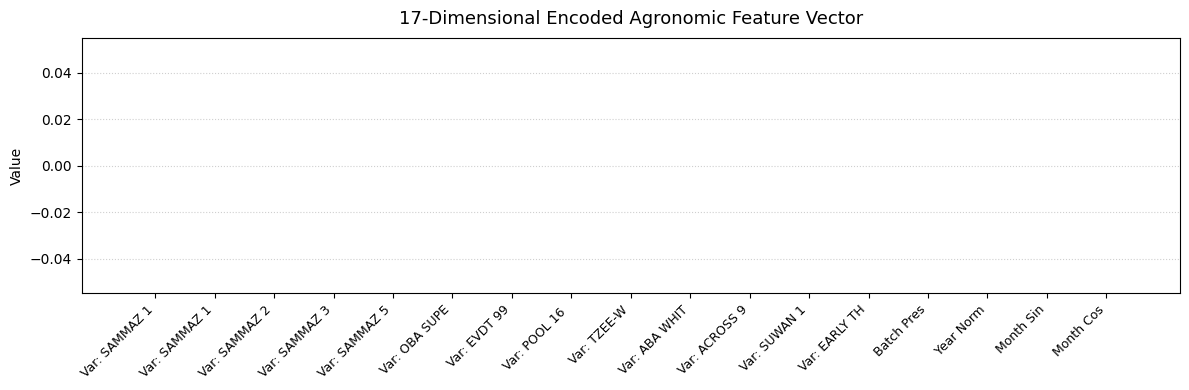

In [4]:
# Encode extracted fields into continuous vector
meta_vector = encode(extracted)

print(f"Encoded Vector Shape: {meta_vector.shape} (dtype: {meta_vector.dtype})")

# Visualize vector components
labels = [f"Var: {v[:8]}" for v in KNOWN_VARIETIES] + ["Batch Pres", "Year Norm", "Month Sin", "Month Cos"]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(meta_vector)), meta_vector, color="#2980b9", alpha=0.85)
ax.set_xticks(range(len(meta_vector)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Value")
ax.set_title("17-Dimensional Encoded Agronomic Feature Vector", fontsize=13, pad=10)
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


In [5]:
# Inspect real metadata annotations from dataset
meta_csv = "data/annotations/labels_with_metadata.csv"
if os.path.exists(meta_csv):
    df_meta = pd.read_csv(meta_csv)
    print(f"Total labeled records: {len(df_meta)}")
    print("\nSample annotated rows:")
    display_cols = ["image_path", "class_name", "crop_variety", "batch_number", "planting_date"]
    print(df_meta[display_cols].dropna().head(5).to_string(index=False))


Total labeled records: 4188

Sample annotated rows:
                                              image_path class_name crop_variety batch_number planting_date
 data/raw/plantvillage/data/Blight/Corn_Blight (100).jpg       NCLB  OBA SUPER 2  BN-2023-011    2023-11-01
data/raw/plantvillage/data/Blight/Corn_Blight (1000).JPG       NCLB    SAMMAZ 50  BN-2023-011    2024-03-15
data/raw/plantvillage/data/Blight/Corn_Blight (1001).JPG       NCLB    ABA WHITE LOT-2024-007    2023-11-01
data/raw/plantvillage/data/Blight/Corn_Blight (1002).JPG       NCLB    SAMMAZ 50  BN-2024-042    2024-03-15
data/raw/plantvillage/data/Blight/Corn_Blight (1004).JPG       NCLB       TZEE-W  BN-2024-042    2024-05-20
